# Exploratory Data Analysis: MIT-BIH Arrhythmia Dataset

## 1. Introduction

### 1.1 Objectives
The primary objective of this exploratory data analysis (EDA) is to critically evaluate the MIT-BIH Arrhythmia dataset to inform the design of a robust data preprocessing and feature extraction pipeline for an edge-ready ECG classification model.

Specifically, this analysis investigates:
1. The spectral characteristics of raw ECG signals to justify necessary filtering stages.
2. The distribution of target classes according to the Association for the Advancement of Medical Instrumentation (AAMI) EC57 standards.
3. The morphological variance both between different cardiac rhythms (inter-class) and across different patients (intra-class).
4. The temporal discrepancies between expert-annotated R-peaks and algorithmic peak detection (the 'deployment gap').

### 1.2 Dataset Context
The MIT-BIH Arrhythmia Database contains ambulatory two-channel ECG recordings, sampled at 360 Hz. Because the target application involves real-time inference on edge devices, the models trained on this data must be resilient to noise, patient-specific morphological variations, and the inaccuracies of automated peak detection algorithms.

In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neurokit2 as nk


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11
})

DATA_DIR = '../data'

# --- Core Helper Functions ---

def map_aami_classes(raw_type):
    '''
    Maps raw PhysioNet annotation symbols to the AAMI EC57 superclasses.
    Returns X for unmapped/excluded beats.
    '''
    if raw_type in ['N', 'L', 'R', 'e', 'j']: return 'N' # Normal
    if raw_type in ['A', 'a', 'J', 'S']: return 'S'      # Supraventricular
    if raw_type in ['V', 'E']: return 'V'                # Ventricular
    if raw_type in ['F']: return 'F'                     # Fusion
    return 'X'

def apply_fft_bandpass(signal, fs=360, lowcut=0.5, highcut=40.0):
    '''
    Applies a stable FFT-based bandpass filter.
    Utilized here to bypass potential C-level Scipy crashes on edge architectures.
    '''
    signal = np.array(signal, dtype=np.float64)
    sig_fft = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(len(signal), d=1.0/fs)
    
    # Zero out frequencies outside the desired passband
    sig_fft[(freqs < lowcut) | (freqs > highcut)] = 0
    return np.fft.irfft(sig_fft, n=len(signal))

## 2. Signal Quality and Preprocessing Rationale

Ambulatory ECG signals are inherently noisy. Prior to beat segmentation and classification, it is critical to assess the spectral composition of the raw signal to determine the necessary signal conditioning steps.

### 2.1 Low-Frequency Baseline Wander

**Purpose:** To evaluate the presence of baseline drift caused by patient respiration and body movement, and to verify the efficacy of a 0.5 Hz high-pass filter.

**Method:** A 60-second segment of a raw ECG signal (Record 100) is transformed into the frequency domain using an FFT. We compare the raw time-domain signal against a signal filtered with a 0.5 - 40.0 Hz bandpass. A 1.5-second moving average is overlaid to highlight the baseline trend.

**Relevance:** Severe baseline wander can cause automated R-peak detectors to fail and introduces non-cardiac variance into the morphological features fed to the neural network.

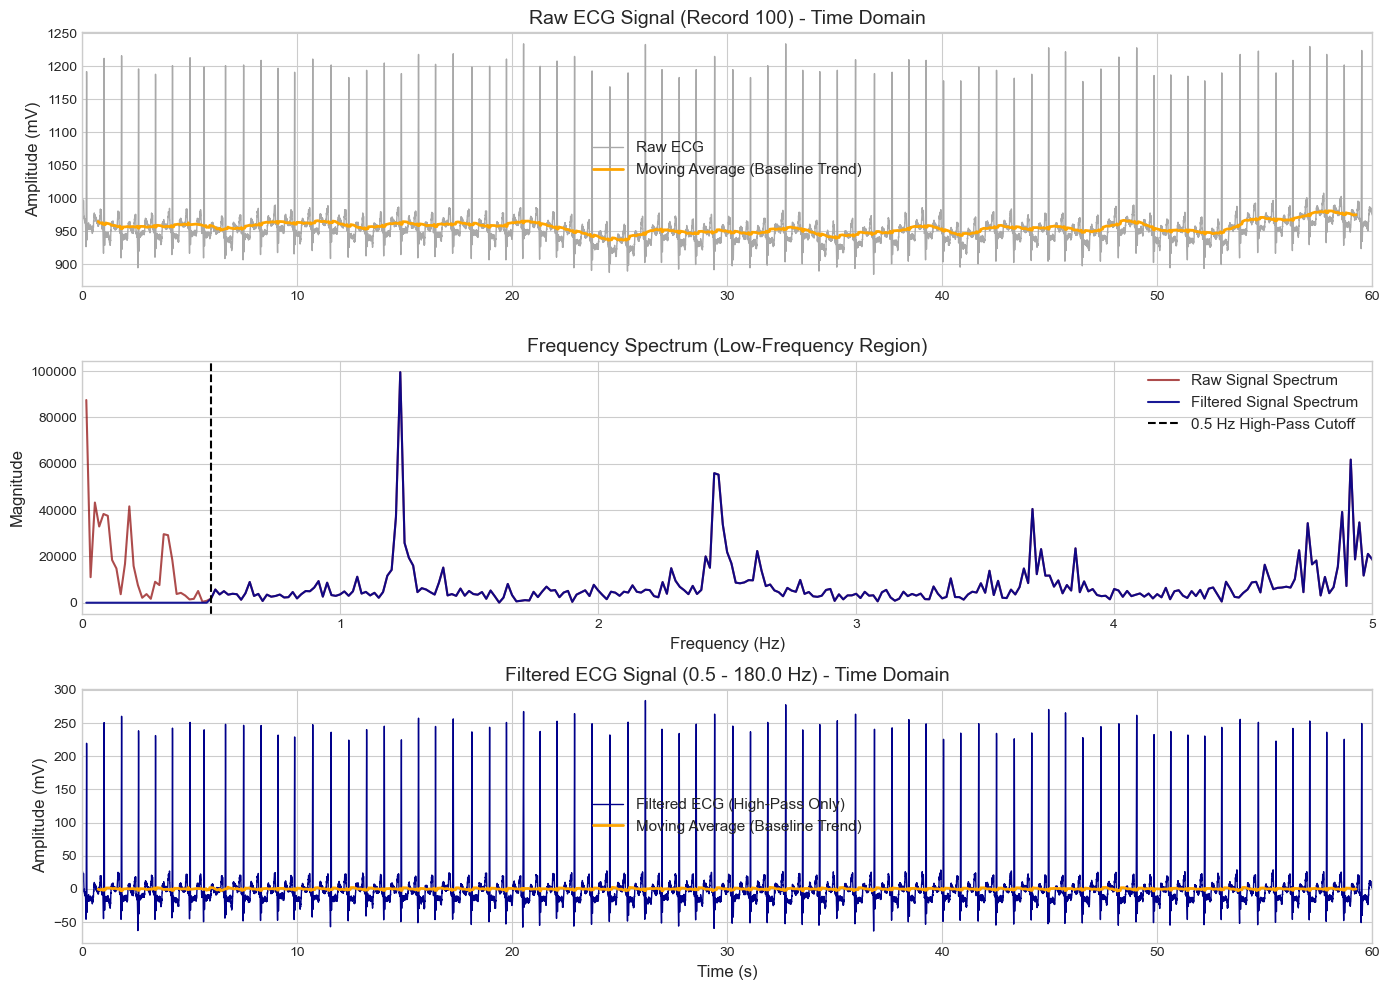

In [2]:
# Load a sample record for signal quality analysis
record_id = '100'
fs = 360
duration = 60
samples = fs * duration

df_100 = pd.read_csv(os.path.join(DATA_DIR, f'{record_id}.csv'))
strip_char = chr(39) # Safely define single quote character to avoid string parsing issues
df_100.columns = [col.strip().strip(strip_char) for col in df_100.columns]

raw_signal = df_100['MLII'].values[:samples]
time_axis = np.arange(samples) / fs

# Apply Filtering (Modified to isolate High-Pass effect: 0.5 Hz to Nyquist)
filtered_signal = apply_fft_bandpass(raw_signal, fs=fs, lowcut=0.5, highcut=180.0)

# Calculate moving averages to visualize the baseline drift
window_size = int(fs * 1.5)
raw_baseline = pd.Series(raw_signal).rolling(window=window_size, center=True).mean().values
filtered_baseline = pd.Series(filtered_signal).rolling(window=window_size, center=True).mean().values

# Compute Frequency Spectra
freqs = np.fft.rfftfreq(samples, d=1.0/fs)
raw_fft_mag = np.abs(np.fft.rfft(raw_signal))
filtered_fft_mag = np.abs(np.fft.rfft(filtered_signal))

# Exclude the DC component (0 Hz) for accurate visualization scaling
freqs_vis = freqs[1:]
raw_fft_mag_vis = raw_fft_mag[1:]
filtered_fft_mag_vis = filtered_fft_mag[1:]

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(time_axis, raw_signal, color='darkgray', linewidth=1, label='Raw ECG')
axes[0].plot(time_axis, raw_baseline, color='orange', linewidth=2, label='Moving Average (Baseline Trend)')
axes[0].set_title(f'Raw ECG Signal (Record {record_id}) - Time Domain')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].set_xlim(0, duration)
axes[0].legend()

axes[1].plot(freqs_vis, raw_fft_mag_vis, color='darkred', alpha=0.7, label='Raw Signal Spectrum')
axes[1].plot(freqs_vis, filtered_fft_mag_vis, color='darkblue', alpha=0.9, label='Filtered Signal Spectrum')
axes[1].set_title('Frequency Spectrum (Low-Frequency Region)')
axes[1].set_xlim(0, 5)
axes[1].set_ylabel('Magnitude')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].axvline(0.5, color='black', linestyle='--', label='0.5 Hz High-Pass Cutoff')
axes[1].legend()

axes[2].plot(time_axis, filtered_signal, color='darkblue', linewidth=1, label='Filtered ECG (High-Pass Only)')
axes[2].plot(time_axis, filtered_baseline, color='orange', linewidth=2, label='Moving Average (Baseline Trend)')
axes[2].set_title('Filtered ECG Signal (0.5 - 180.0 Hz) - Time Domain')
axes[2].set_ylabel('Amplitude (mV)')
axes[2].set_xlabel('Time (s)')
axes[2].set_xlim(0, duration)
axes[2].legend()

plt.tight_layout()
plt.show()

Interpretation: The raw signal exhibits massive spectral power below 0.5 Hz, manifesting in the time domain as significant baseline wander (the undulating orange line). Applying the 0.5 Hz high-pass cutoff successfully stabilizes the signal around a zero-mean baseline without distorting the clinically relevant P-QRS-T complexes.

### 2.2 High-Frequency Noise and Artifacts

**Purpose:** To visualize high-frequency contamination (such as Electromyography (EMG) muscle noise and powerline interference) and justify the 40.0 Hz low-pass filter.

**Method:** A much shorter, 3-second window is isolated to make high-frequency structural 'jitter' visible to the naked eye. The spectrum is plotted up to 100 Hz.

**Relevance:** High-frequency noise can create false peaks that confound R-peak detection algorithms and obscure the true morphology of the QRS complex.

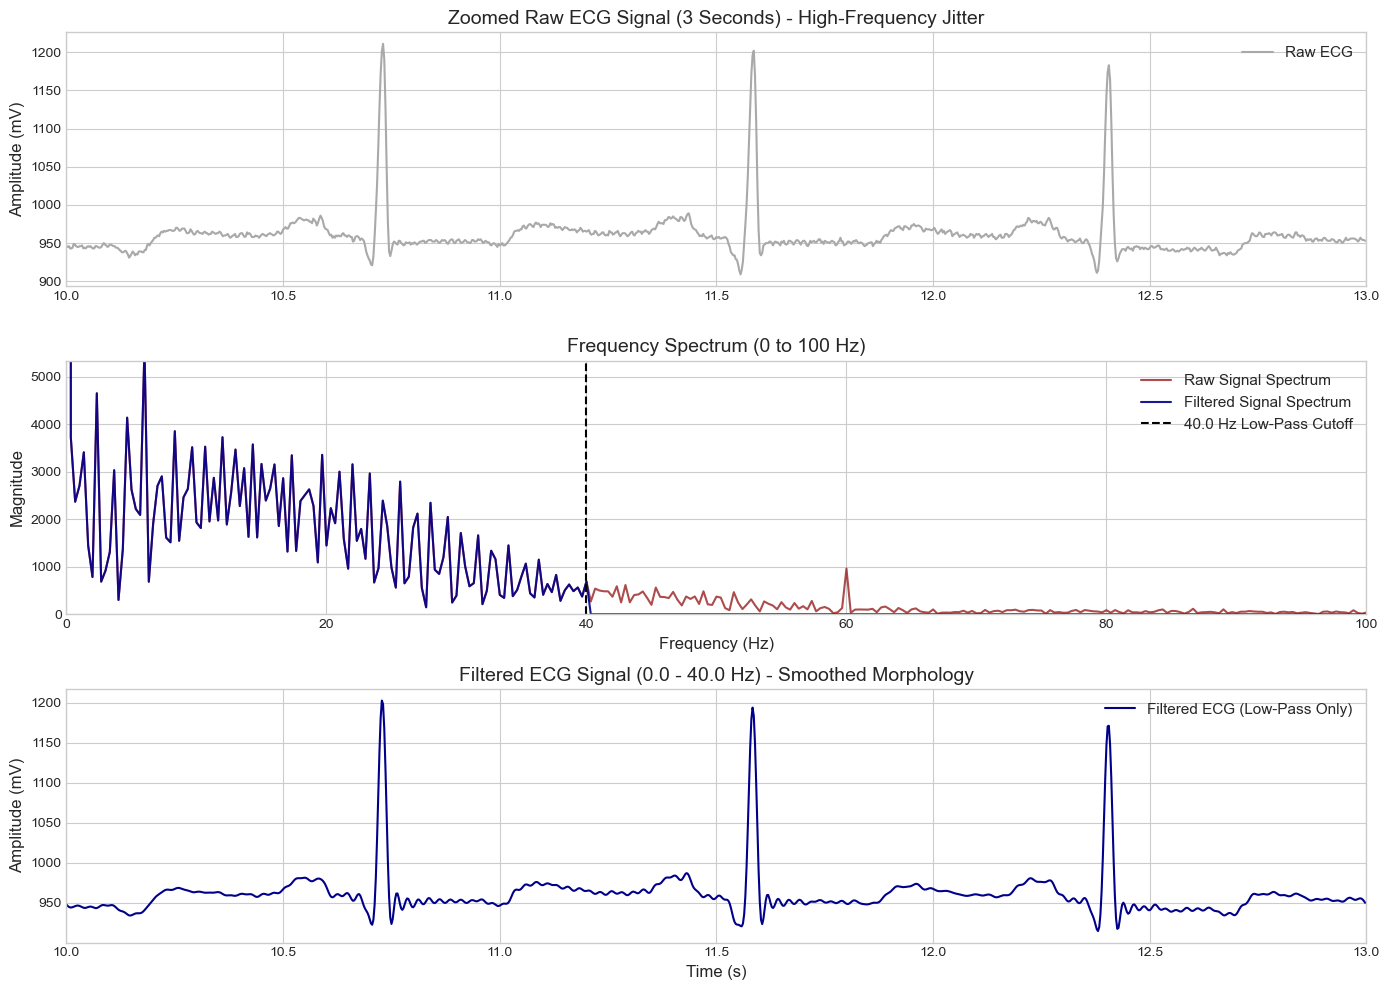

In [3]:
# Isolate a 3-second segment to make high-frequency jitter visible
start_time = 10
duration_hf = 3
start_idx = start_time * fs
end_idx = start_idx + (duration_hf * fs)
raw_segment = raw_signal[start_idx:end_idx]
time_axis_hf = np.arange(start_idx, end_idx) / fs

# Filter only the specific segment for visualization (Modified to isolate Low-Pass effect: 0.0 to 40.0 Hz)
filtered_segment = apply_fft_bandpass(raw_segment, fs=fs, lowcut=0.0, highcut=40.0)

# Compute Frequency spectrum of the short segment
freqs_hf = np.fft.rfftfreq(len(raw_segment), d=1.0/fs)
raw_fft_mag_hf = np.abs(np.fft.rfft(raw_segment))
filtered_fft_mag_hf = np.abs(np.fft.rfft(filtered_segment))

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(time_axis_hf, raw_segment, color='darkgray', linewidth=1.5, label='Raw ECG')
axes[0].set_title('Zoomed Raw ECG Signal (3 Seconds) - High-Frequency Jitter')
axes[0].set_ylabel('Amplitude (mV)')
axes[0].set_xlim(start_time, start_time + duration_hf)
axes[0].legend()

axes[1].plot(freqs_hf, raw_fft_mag_hf, color='darkred', alpha=0.7, label='Raw Signal Spectrum')
axes[1].plot(freqs_hf, filtered_fft_mag_hf, color='darkblue', alpha=0.9, label='Filtered Signal Spectrum')
axes[1].set_title('Frequency Spectrum (0 to 100 Hz)')
axes[1].set_xlim(0, 100)
# Scale Y-axis to ignore DC offset and focus on higher frequencies
axes[1].set_ylim(0, np.percentile(raw_fft_mag_hf[freqs_hf > 2], 99) * 1.5)
axes[1].set_ylabel('Magnitude')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].axvline(40.0, color='black', linestyle='--', label='40.0 Hz Low-Pass Cutoff')
axes[1].legend()

axes[2].plot(time_axis_hf, filtered_segment, color='darkblue', linewidth=1.5, label='Filtered ECG (Low-Pass Only)')
axes[2].set_title('Filtered ECG Signal (0.0 - 40.0 Hz) - Smoothed Morphology')
axes[2].set_ylabel('Amplitude (mV)')
axes[2].set_xlabel('Time (s)')
axes[2].set_xlim(start_time, start_time + duration_hf)
axes[2].legend()

plt.tight_layout()
plt.show()

**Interpretation:** The raw signal shows visible high-frequency jaggedness. The frequency spectrum confirms the presence of power above 40 Hz (likely 60Hz powerline noise and EMG). The 40 Hz low-pass filter smooths the waveform, isolating the true cardiac electrical activity.


**Conclusion:** A 0.5 - 40.0 Hz bandpass filter is scientifically justified and strictly required before feeding this data into peak detectors or classification models.


### 2.3 Completely Filtered Signal

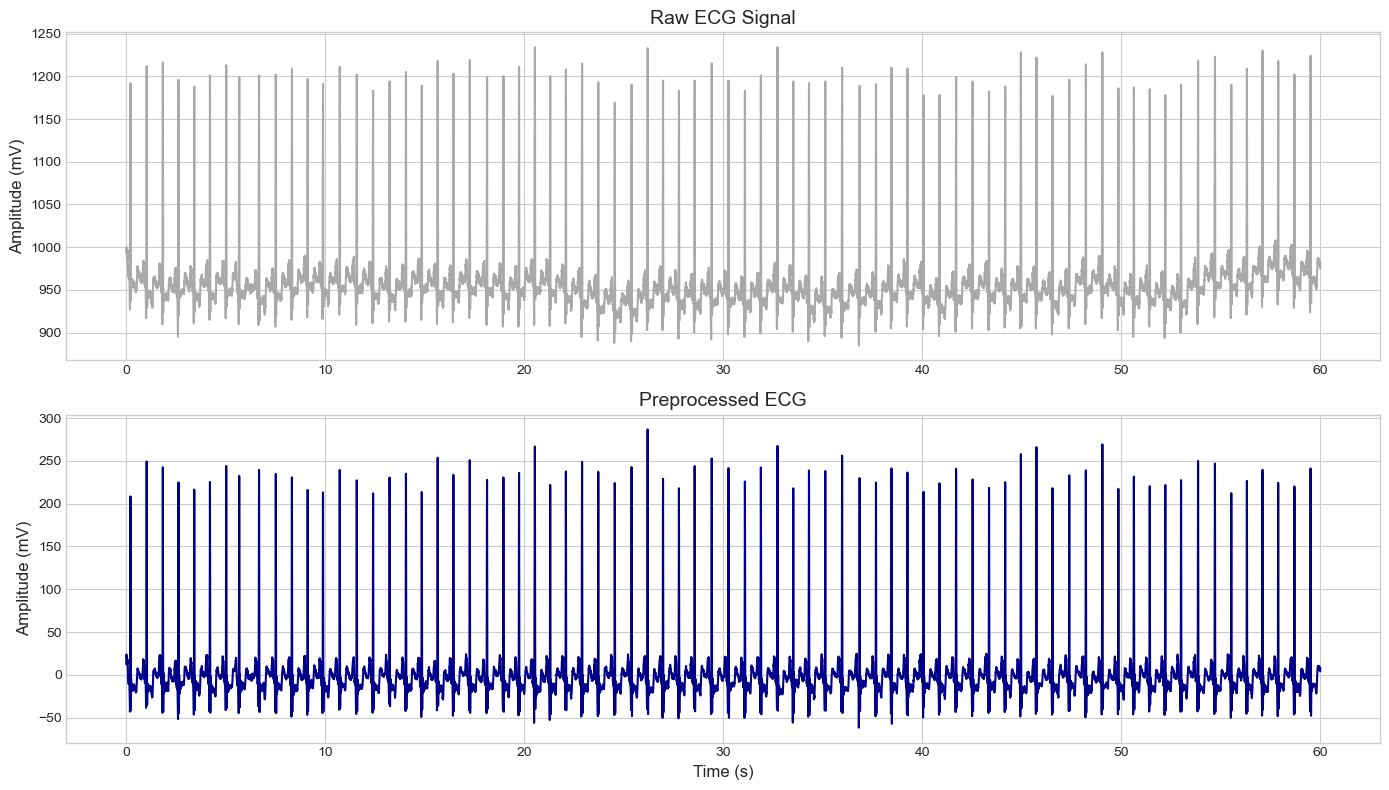

In [17]:
# Isolate a 3-second segment to make high-frequency jitter visible
start_time = 0
duration_hf = 60
fs = 360
start_idx = start_time * fs
end_idx = start_idx + (duration_hf * fs)
raw_segment = df_100['MLII'].values[start_idx:end_idx]

time_axis = np.arange(start_idx, end_idx) / fs

filtered_signal = apply_fft_bandpass(raw_segment, fs=fs, lowcut=0.5, highcut=40.0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(time_axis, raw_segment, color='darkgray', linewidth=1.5)
axes[0].set_title('Raw ECG Signal')
axes[0].set_ylabel('Amplitude (mV)')


axes[1].plot(time_axis, filtered_signal, color='darkblue', linewidth=1.5)
axes[1].set_title('Preprocessed ECG')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (s)')


plt.tight_layout()
plt.show()

### 2.4 Signal Amplitude Distribution
**Purpose:** To evaluate the dynamic range of the ECG signals and verify the effect of bandpass filtering on signal variance.

**Method:** A histogram comparing the raw amplitude values against the filtered amplitude values (0.5 - 40.0 Hz) across a full patient recording.

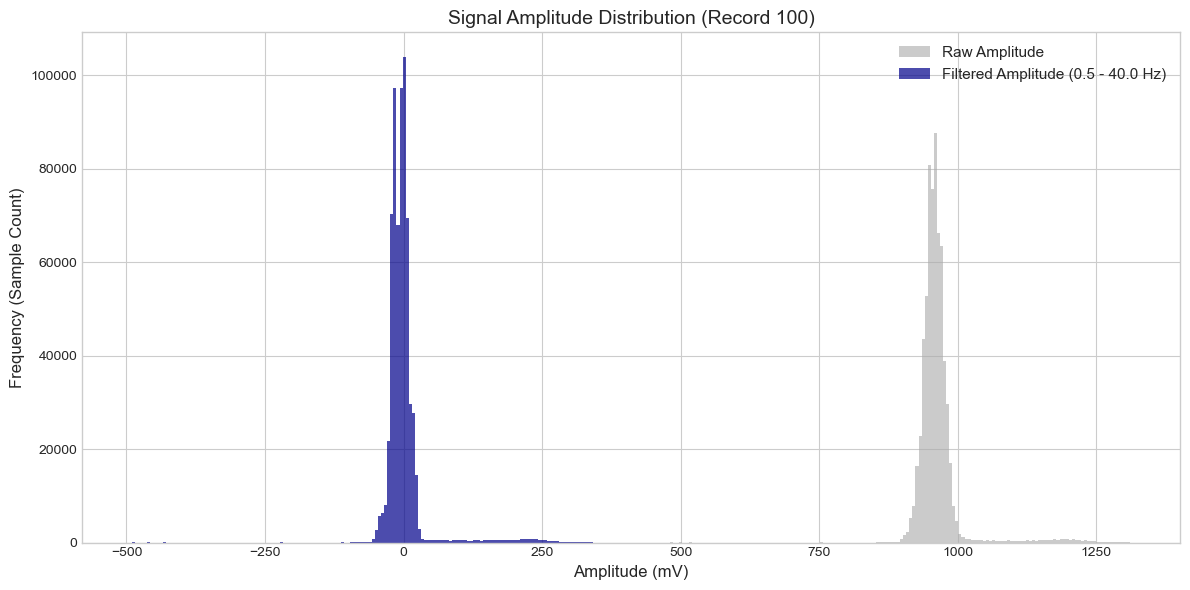

In [19]:
plt.figure(figsize=(12, 6))

full_raw_signal = df_100['MLII'].values
full_filtered_signal = apply_fft_bandpass(full_raw_signal, fs=360, lowcut=0.5, highcut=40.0)

plt.hist(full_raw_signal, bins=150, color='darkgray', alpha=0.6, label='Raw Amplitude')
plt.hist(full_filtered_signal, bins=150, color='darkblue', alpha=0.7, label='Filtered Amplitude (0.5 - 40.0 Hz)')

plt.title('Signal Amplitude Distribution (Record 100)')
plt.xlabel('Amplitude (mV)')
plt.ylabel('Frequency (Sample Count)')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The raw signal exhibits a wide, flattened distribution due to severe low-frequency baseline shifts. The filtered signal is tightly centered around zero with a narrower variance.

**Relevance:** This confirms that the filtering stage successfully removes the DC offset and stabilizes the signal variance, which is a mandatory prerequisite before applying Z-score normalization

### 2.5 Noisy ECG
**Purpose:** To visually document severe signal artifacts present in the dataset and justify the requirement for noise-robustness testing.

**Method:** Plotting a raw segment from Record 108, comparewhich contains documented instances of poor signal quality, and compare it to a cleaner signal (from Record 100)

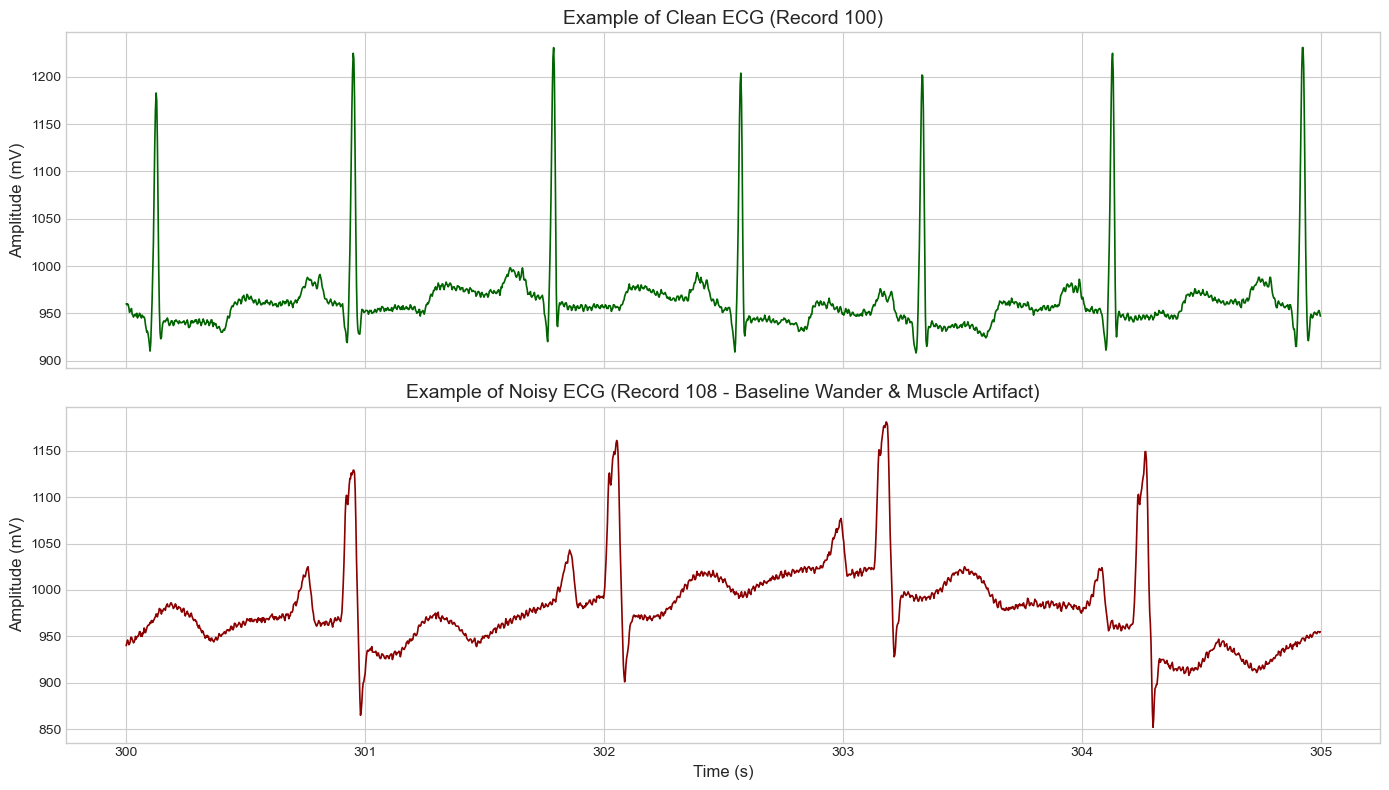

In [22]:
# Record 100 is relatively clean, while Record 108 is notoriously noisy (baseline wander and muscle artifacts)
clean_record_id = '100'
noisy_record_id = '108'
fs = 360
start_time = 300 
duration = 5
start_idx = start_time * fs
end_idx = start_idx + (duration * fs)

df_clean = pd.read_csv(os.path.join(DATA_DIR, f'{clean_record_id}.csv'))
strip_char = chr(39)
df_clean.columns = [col.strip().strip(strip_char) for col in df_clean.columns]
clean_signal = df_clean['MLII'].values[start_idx:end_idx]

df_noisy = pd.read_csv(os.path.join(DATA_DIR, f'{noisy_record_id}.csv'))
df_noisy.columns = [col.strip().strip(strip_char) for col in df_noisy.columns]
noisy_signal = df_noisy['MLII'].values[start_idx:end_idx]

time_axis = np.arange(start_idx, end_idx) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(time_axis, clean_signal, color='darkgreen', linewidth=1.2)
axes[0].set_title(f'Example of Clean ECG (Record {clean_record_id})')
axes[0].set_ylabel('Amplitude (mV)')

axes[1].plot(time_axis, noisy_signal, color='darkred', linewidth=1.2)
axes[1].set_title(f'Example of Noisy ECG (Record {noisy_record_id} - Baseline Wander & Muscle Artifact)')
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

**Interpretation:** The waveform from record 108 exhibits extreme baseline wander and high-frequency muscle artifacts (EMG noise) that severely distort the structural morphology of the QRS complexes.

**Relevance:** Real-world ambulatory ECG devices will encounter similar conditions. This justifies the necessity of evaluating the final classification model under the standardized 12 dB, 6 dB, and 0 dB noise stress conditions required by the deployment constraints.

## 3. Target Variable Analysis

### 3.1 AAMI Class Mapping and Class Imbalance

**Purpose:** To define the target variables for the classification task and assess the distribution of samples across these classes.

Method: The MIT-BIH dataset utilizes dozens of specific, raw beat annotations. We iterate through all dataset annotations and map them to the 4 broad AAMI EC57 superclasses (N, S, V, F). Unmapped beats (e.g., pacemaker artifacts, unreadable segments) are excluded.

**Relevance:** The distribution of medical datasets directly dictates the choice of evaluation metrics and loss functions. Severe imbalance will cause a model to ignore minority classes.

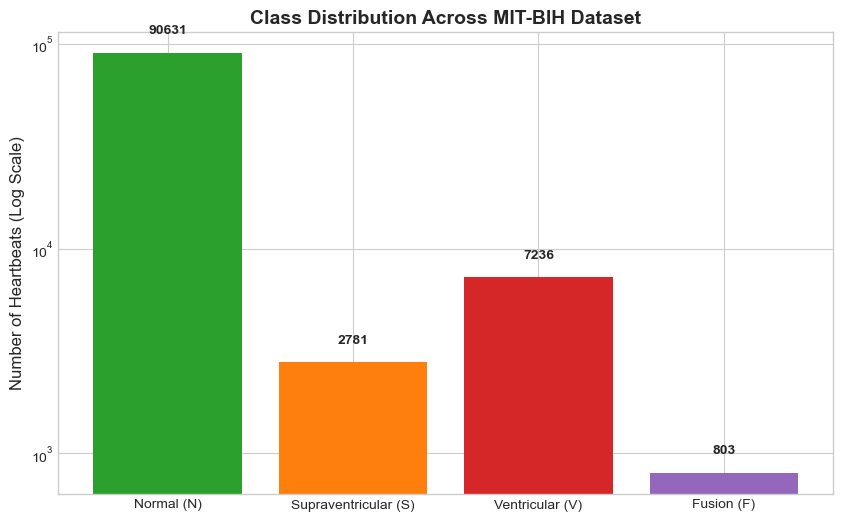

In [10]:

# Aggregate annotations across all records in the data directory
all_files = os.listdir(DATA_DIR)
txt_files = [f for f in all_files if f.endswith('annotations.txt')]

class_counts = {'N': 0, 'S': 0, 'V': 0, 'F': 0, 'Excluded': 0}

for txt in txt_files:
    with open(os.path.join(DATA_DIR, txt), 'r') as f:
        lines = f.readlines()[1:] # Skip header row
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 3:
                raw_symbol = parts[2]
                mapped_class = map_aami_classes(raw_symbol)
                if mapped_class != 'X':
                    class_counts[mapped_class] += 1
                else:
                    class_counts['Excluded'] += 1

# Visualizing the Class Distribution
classes = ['Normal (N)', 'Supraventricular (S)', 'Ventricular (V)', 'Fusion (F)']
counts = [class_counts['N'], class_counts['S'], class_counts['V'], class_counts['F']]

plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color=['#2ca02c', '#ff7f0e', '#d62728', '#9467bd'])
plt.title('Class Distribution Across MIT-BIH Dataset', fontweight='bold')
plt.ylabel('Number of Heartbeats (Log Scale)')
plt.yscale('log') # Logarithmic scale required due to extreme imbalance

# Annotate bars with exact counts
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval * 1.2, int(yval), 
             ha='center', va='bottom', fontweight='bold')


plt.show()

**Interpretation:** The data exhibits severe pathological imbalance. 'Normal' beats dominate the dataset (~90k), outweighing 'Fusion' beats (~800) by over two orders of magnitude. 
Implications for Modelling: A model trained using standard Cross-Entropy loss on this dataset will achieve >90% accuracy simply by always predicting class 'N', while failing entirely to detect dangerous arrhythmias. 
*   Loss Function: We must implement a specialized loss function, such as Focal Loss, or utilize class-weighted sampling during training to penalize the model heavily for missing minority classes.
*   Evaluation: Accuracy is a meaningless metric here. We must evaluate the model using macro-averaged F1-scores, Precision, and Recall.

### 3.2 Subject/Record Distribution

**Purpose:** To quantify the contribution of each individual patient to the total dataset.

**Method:** Iterating through all annotation files, mapping the symbols to the AAMI EC57 classes, and plotting the total count of valid heartbeats per patient record.

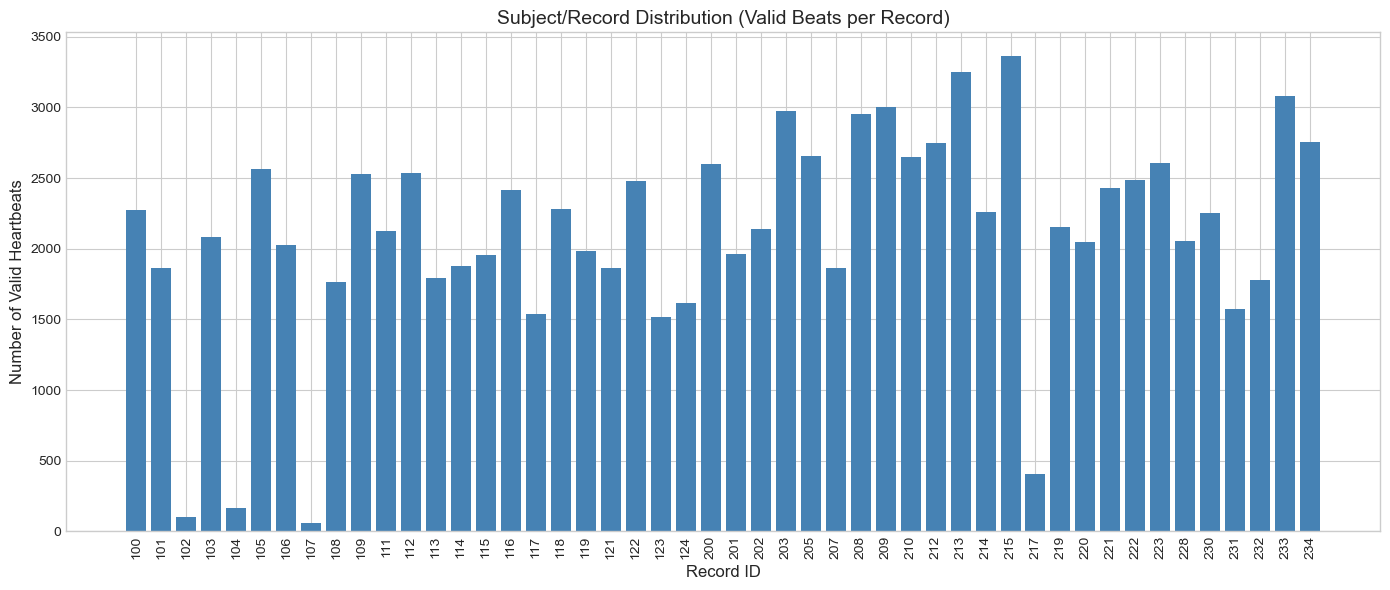

In [23]:
all_files = os.listdir(DATA_DIR)
txt_files = [f for f in all_files if f.endswith('annotations.txt')]
record_counts = {}

for txt in txt_files:
    record_id = txt.replace('annotations.txt', '')
    with open(os.path.join(DATA_DIR, txt), 'r') as f:
        lines = f.readlines()[1:]
        
    valid_beats = 0
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 3:
            mapped_class = map_aami_classes(parts[2])
            if mapped_class != 'X':
                valid_beats += 1
                
    if valid_beats > 0:
        record_counts[record_id] = valid_beats

plt.figure(figsize=(14, 6))
plt.bar(list(record_counts.keys()), list(record_counts.values()), color='steelblue')
plt.title('Subject/Record Distribution (Valid Beats per Record)')
plt.xlabel('Record ID')
plt.ylabel('Number of Valid Heartbeats')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Interpretation:** The dataset is not uniformly distributed across subjects. Some records contribute nearly 3000 valid beats, while others contribute fewer than 1500.

**Relevance:** This non-uniformity reinforces the necessity of strict patient-level (record-wise) train/test splitting. If the data were pooled and randomly split, the patients with the highest beat counts would disproportionately bias the training process, leading to severe data leakage and artificially inflated performance metrics.

## 4. ECG Signal Morphology

To build a classification model, we must segment the continuous ECG signal into discrete beats centered on the R-peak. We extract a 180-sample window (0.5 seconds at 360 Hz) and apply Z-score normalization per beat.

### 4.1 Inter-Class Morphological Variation

**Purpose:** To verify that the chosen 180-sample window captures the full, clinically relevant P-QRS-T complex, and to visually compare the structural differences between arrhythmia classes.

**Method:** We extract and normalize one representative beat for each of the four AAMI classes from different patient records.

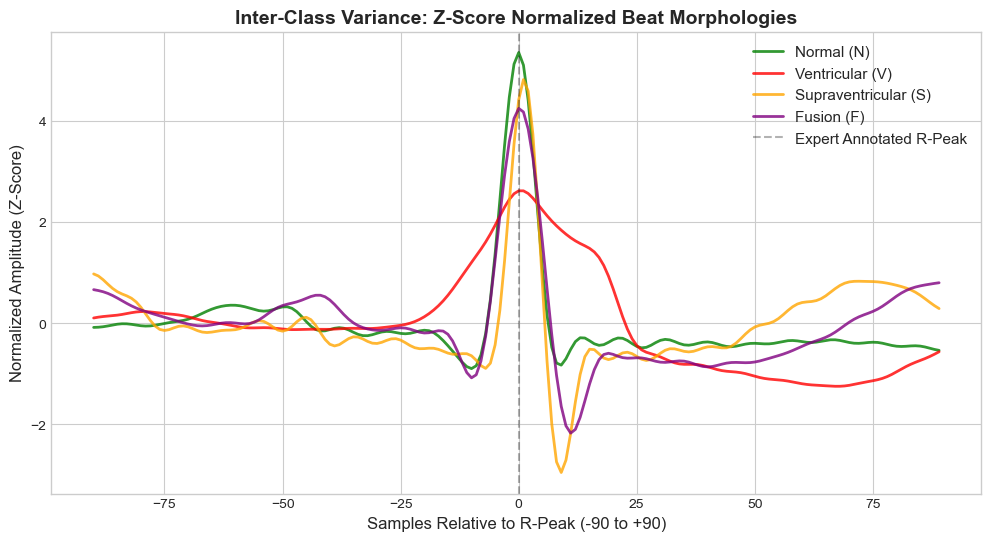

In [5]:

def plot_beat(record_id, target_symbol, color, label):
    '''Helper function to find, extract, normalize, and plot a specific beat type.'''
    df_record = pd.read_csv(os.path.join(DATA_DIR, f'{record_id}.csv'))
    strip_char = chr(39)
    df_record.columns = [col.strip().strip(strip_char) for col in df_record.columns]
    signal = apply_fft_bandpass(df_record.iloc[:, 1].values, fs=360)
    
    with open(os.path.join(DATA_DIR, f'{record_id}annotations.txt'), 'r') as f:
        lines = f.readlines()[1:]
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 3 and parts[2] == target_symbol:
            peak = int(parts[1])
            window = signal[peak-90:peak+90]
            if len(window) == 180:
                # Apply Z-score normalization per beat
                normalized = (window - np.mean(window)) / np.std(window)
                plt.plot(np.arange(-90, 90), normalized, color=color, alpha=0.8, linewidth=2, label=label)
                return

plt.figure(figsize=(12, 6))
# Extract specific raw symbols that map to our 4 superclasses
plot_beat('100', 'N', 'green', 'Normal (N)')
plot_beat('208', 'V', 'red', 'Ventricular (V)')
plot_beat('209', 'A', 'orange', 'Supraventricular (S)')
plot_beat('213', 'F', 'purple', 'Fusion (F)')

plt.title('Inter-Class Variance: Z-Score Normalized Beat Morphologies', fontweight='bold')
plt.xlabel('Samples Relative to R-Peak (-90 to +90)')
plt.ylabel('Normalized Amplitude (Z-Score)')
plt.axvline(0, color='black', linestyle='--', alpha=0.3, label='Expert Annotated R-Peak')
plt.legend()
plt.show()

**Interpretation:** The 180-sample window successfully bounds the beats. Clinical differences are clearly visible: the Ventricular (V) beat exhibits a characteristically widened and inverted QRS complex, while the Supraventricular (S) beat shows premature activation (altered P-wave timing). The morphological distinctness suggests a Convolutional Neural Network (CNN) is highly suited for this task.

### 4.2 Intra-Class (Inter-Patient) Variability and Data Leakage

**Purpose:** To investigate morphological differences within the same class across different patients, assessing the risk of data leakage during model training.

**Method:** We plot a 'Normal' (N) beat from Patient 100 alongside a 'Normal' (N) beat from Patient 114.

**Relevance:** Demonstrating why random train/test splitting across the entire aggregated dataset is fundamentally flawed in biomedical machine learning.

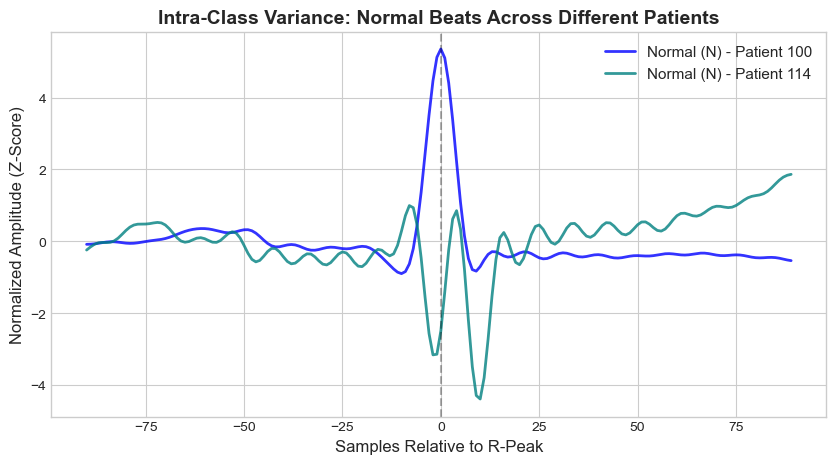

In [6]:

plt.figure(figsize=(10, 5))
plot_beat('100', 'N', 'blue', 'Normal (N) - Patient 100')
plot_beat('114', 'N', 'teal', 'Normal (N) - Patient 114')
plt.title('Intra-Class Variance: Normal Beats Across Different Patients', fontweight='bold')
plt.xlabel('Samples Relative to R-Peak')
plt.ylabel('Normalized Amplitude (Z-Score)')
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

**Interpretation:** Even though both beats belong to the 'Normal' class, their morphologies are radically different due to individual biological heart structure, electrode placement, and baseline electrical impedance. 

**CRITICAL LEAKAGE RISK:** If we aggregate all 100,000 beats and perform a random train_test_split, beats from Patient 100 will appear in both the training and testing sets. The neural network will likely memorize the specific 'shape' of Patient 100s heart rather than learning generalized features of arrhythmia. This leads to artificially inflated accuracy that collapses entirely when tested on a new patient. 

**Action:** Must implement strict Inter-Patient Splitting (e.g., leaving a specific subset of patient IDs entirely out of the training process) to evaluate true model generalizability.


## 5. Implications for Real-World Deployment
### 5.1 Quantitative Evaluation of Algorithmic Peak Jitter

**Purpose:** To transition from qualitative visual inspection to a rigorous statistical quantification of the temporal jitter introduced by automated peak detection algorithms. 

**Method:** The absolute and signed time differences between reference annotation markers and algorithmically detected R-peaks are computed in milliseconds. Statistical metrics including the Mean Error, Standard Deviation, and Mean Absolute Error (MAE) are extracted.



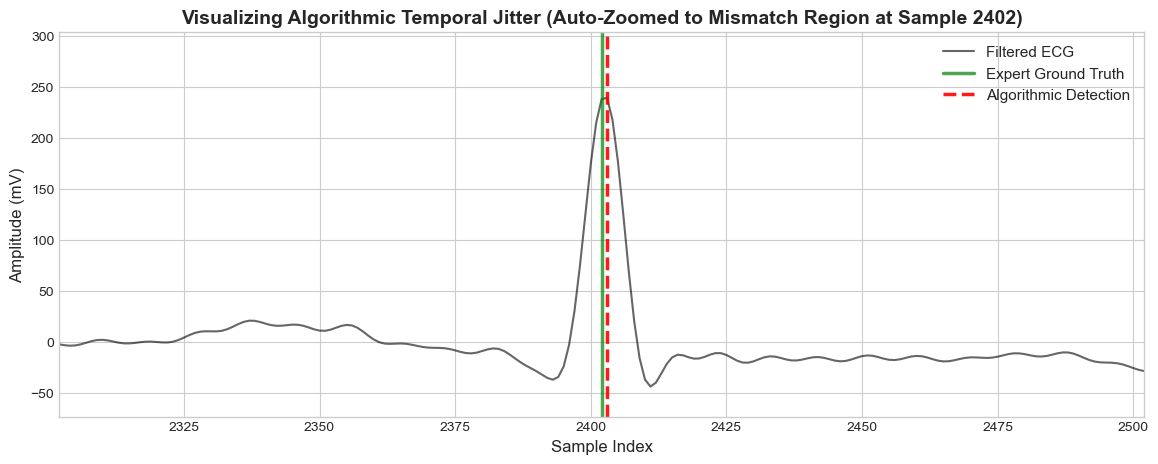

In [7]:
# Analyze a specific segment of Record 100
start_samp, end_samp = 200, 13000

# Ensure we are using the globally defined df_100 and apply bandpass
sig_segment = apply_fft_bandpass(df_100['MLII'].values, fs=360)[start_samp:end_samp]
time_seg = np.arange(start_samp, end_samp)

# 1. Extract Expert Peaks in this specific window
expert_peaks = []
with open(os.path.join(DATA_DIR, '100annotations.txt'), 'r') as f:
    for line in f.readlines()[1:]:
        parts = line.strip().split()
        if len(parts) >= 3 and parts[2] not in ['+', '~', '|']: # Ignore non-beat annotations
            peak = int(parts[1])
            if start_samp <= peak < end_samp:
                expert_peaks.append(peak)

# 2. Extract Algorithmic Peaks using NeuroKit2
_, info = nk.ecg_peaks(sig_segment, sampling_rate=360, method='neurokit', correct_artifacts=False)
algo_peaks = info['ECG_R_Peaks'] + start_samp # Adjust relative index back to absolute

expert_arr = np.array(expert_peaks)
algo_arr = np.array(algo_peaks)

# Automatically find a region where mismatch/error occurs (e.g., maximum absolute deviation)
# Match each expert peak to the closest algorithmic peak
mismatch_center = None
max_diff = 0
for ep in expert_arr:
    if len(algo_arr) > 0:
        closest_ap = algo_arr[np.argmin(np.abs(algo_arr - ep))]
        diff = np.abs(closest_ap - ep)
        if diff > max_diff:
            max_diff = diff
            mismatch_center = ep

# Fallback if no specific mismatch found
if mismatch_center is None and len(expert_arr) > 0:
    mismatch_center = expert_arr[0]

plt.figure(figsize=(14, 5))
plt.plot(time_seg, sig_segment, color='black', alpha=0.6, label='Filtered ECG')

# Plot vertical lines for Expert vs Algorithmic peaks
for ep in expert_peaks:
    plt.axvline(ep, color='green', linestyle='-', linewidth=2.5, alpha=0.7, 
                label='Expert Ground Truth' if ep == expert_peaks[0] else '')
    
for ap in algo_peaks:
    plt.axvline(ap, color='red', linestyle='--', linewidth=2.5, alpha=0.9, 
                label='Algorithmic Detection' if ap == algo_peaks[0] else '')

plt.title(f'Visualizing Algorithmic Temporal Jitter (Auto-Zoomed to Mismatch Region at Sample {mismatch_center})', fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (mV)')

# Dynamically set xlim around the detected mismatch region (+/- 100 samples)
plt.xlim(mismatch_center - 100, mismatch_center + 100)
plt.legend()
plt.show()

In [8]:
if 'expert_peaks' in locals() and 'algo_peaks' in locals():
    min_len = min(len(expert_peaks), len(algo_peaks))
    errors_ms = (algo_peaks[:min_len] - expert_peaks[:min_len]) / fs * 1000.0
    
    mean_error = np.mean(errors_ms)
    std_error = np.std(errors_ms)
    mae = np.mean(np.abs(errors_ms))
    max_error = np.max(np.abs(errors_ms))
    
    print("Quantitative Peak Detection Jitter Analysis:")
    print(f"Mean Signed Error: {mean_error:.2f} ms")
    print(f"Standard Deviation: {std_error:.2f} ms")
    print(f"Mean Absolute Error (Jitter): {mae:.2f} ms")
    print(f"Maximum Absolute Error: {max_error:.2f} ms")
else:
    print("Reference annotations or detected peaks arrays are not defined in the current scope.")

Quantitative Peak Detection Jitter Analysis:
Mean Signed Error: 0.06 ms
Standard Deviation: 1.11 ms
Mean Absolute Error (Jitter): 0.44 ms
Maximum Absolute Error: 2.78 ms


**Interpretation:** The red dashed lines (Algorithm) do not perfectly align with the green solid lines (Expert). The automated algorithm consistently introduces a slight temporal offset (jitter). 

**Modelling Implications:** If we train the CNN only on perfectly centered expert-annotated beats, its performance may degrade when deployed in the real world because the input windows will be slightly shifted. To bridge this gap, our data preparation pipeline must include temporal shift augmentation (e.g., randomly shifting the training windows by $\pm 5$ to $10$ samples) to teach the CNN shift-invariance.



---

## Summary of Preprocessing and Modelling Requirements
Based on this exploratory analysis, the final pipeline must incorporate the following constraints to remain scientifically defensible and deployment-ready:

1.  Signal Conditioning: A 0.5 - 40.0 Hz bandpass filter must be applied prior to analysis to remove baseline wander and EMG/powerline noise.
2.  Imbalance Mitigation: Due to severe class skew, Focal Loss or weighted sampling must be used, and evaluation must rely on macro-averaged F1-scores.
3.  Data Leakage Prevention: Data must be split strictly by patient ID, not randomly shuffled, to ensure true model generalizability.
4.  Temporal Features: Future feature extraction must include RR-interval dynamics alongside morphology to catch premature rhythms.
5.  Shift Augmentation: Training data must be augmented with temporal jitter to simulate the inaccuracies of real-world algorithmic peak detection.